In [4]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from sklearn.metrics import classification_report, confusion_matrix
from zipfile import ZipFile

## Link para o dataset: [Posturas](https://drive.google.com/drive/folders/1XRoK-tELYSyRiXinRik8VVeiMTjdPTLQ?usp=sharing)




In [5]:
with ZipFile('/content/Posturas.zip', 'r') as zip_ref:
    zip_ref.extractall('Posturas')

In [6]:
dataset = "/content/Posturas/Posturas"

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.3
)

img_size = (224, 224)
batch_size = 32

train_data = datagen.flow_from_directory(
    dataset,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='training',
    seed=42,
    color_mode='grayscale'
)

val_data = datagen.flow_from_directory(
    dataset,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation',
    seed=42,
    color_mode='grayscale'
)

class_names = list(train_data.class_indices.keys())
print("Classes:", class_names)

model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(*img_size, 1)),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(len(class_names), activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

Found 420 images belonging to 3 classes.
Found 180 images belonging to 3 classes.
Classes: ['Deitado', 'Levantado', 'Sentado']


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history = model.fit(train_data, validation_data=val_data, epochs=10)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 53s 4s/step - accuracy: 0.4392 - loss: 1.8454 - val_accuracy: 0.7611 - val_loss: 0.6117
Epoch 2/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 44s 3s/step - accuracy: 0.7608 - loss: 0.5475 - val_accuracy: 0.7833 - val_loss: 0.5792
Epoch 3/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 83s 3s/step - accuracy: 0.8890 - loss: 0.3234 - val_accuracy: 0.7889 - val_loss: 0.7064
Epoch 4/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 44s 3s/step - accuracy: 0.9747 - loss: 0.0994 - val_accuracy: 0.7667 - val_loss: 0.8276
Epoch 5/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 45s 3s/step - accuracy: 0.9883 - loss: 0.0468 - val_accuracy: 0.7833 - val_loss: 0.8566
Epoch 6/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 44s 3s/step - accuracy: 1.0000 - loss: 0.0068 - val_accuracy: 0.7944 - val_loss: 0.9470
Epoch 7/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 44s 3s/step - accuracy: 1.0000 - loss: 0.0024 - val_accuracy: 0.8000 - val_loss: 1.0977
Epoch 8/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 44s 3s/step - accuracy: 1.0000 - loss: 0.0012 - val_accuracy: 0.7944 - val_loss:

In [8]:
val_data.reset()

y_pred = model.predict(val_data)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = val_data.classes

from sklearn.metrics import confusion_matrix, classification_report

print("\nMatriz de Confusão:")
print(confusion_matrix(y_true, y_pred_classes))

print("\nRelatório de Classificação CNN:")
print(classification_report(y_true, y_pred_classes, target_names=class_names))


6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 740ms/step

Matriz de Confusão:
[[18 19 23]
 [22 21 17]
 [14 21 25]]

Relatório de Classificação CNN:
              precision    recall  f1-score   support

     Deitado       0.33      0.30      0.32        60
   Levantado       0.34      0.35      0.35        60
     Sentado       0.38      0.42      0.40        60

    accuracy                           0.36       180
   macro avg       0.35      0.36      0.35       180
weighted avg       0.35      0.36      0.35       180



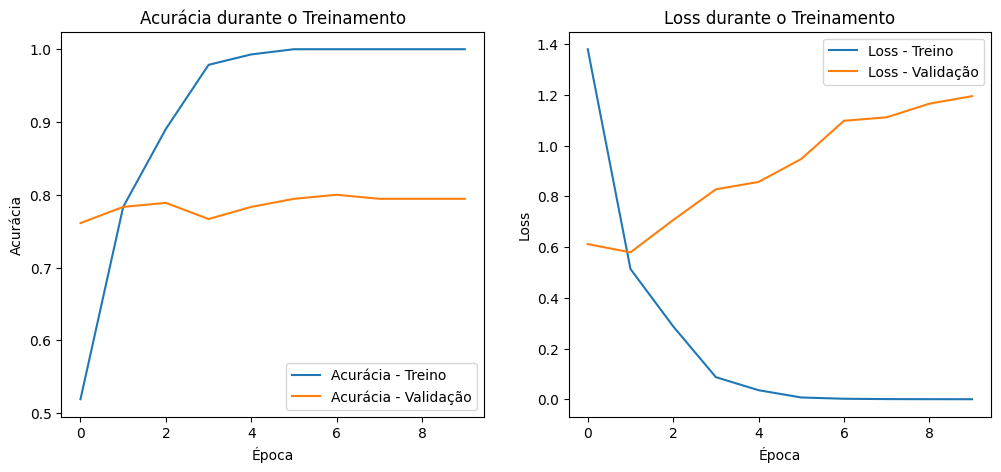

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Acurácia - Treino')
plt.plot(history.history['val_accuracy'], label='Acurácia - Validação')
plt.title('Acurácia durante o Treinamento')
plt.xlabel('Época')
plt.ylabel('Acurácia')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Loss - Treino')
plt.plot(history.history['val_loss'], label='Loss - Validação')
plt.title('Loss durante o Treinamento')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()

plt.show()
